$$\Huge \text { Deep Learning Handwritten Digit Prediction  }$$





<p style="font-family: 'Courier New', monospace; text-align: Justified;">
This project leverages deep learning to predict handwritten digits using the MINT framework (hypothetically referring to a minimalist deep learning setup or a specific library/tool, assuming "mint" is a typo or shorthand). A convolutional neural network (CNN) is trained on a dataset like MNIST, which contains 28x28 grayscale images of digits (0-9). The model learns to extract features such as edges and shapes, enabling accurate classification of handwritten digits. The process involves preprocessing the images, designing a CNN architecture with layers like convolution, pooling, and fully connected layers, and optimizing it using a loss function (e.g., cross-entropy) and an optimizer (e.g., Adam). The result is a robust system capable of recognizing handwritten digits with high accuracy, adaptable for applications like digit recognition in forms or postal codes.
</p>


In [1]:
!pip install tensorflow
# Deep learning library

# Data *Loading*

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

2025-04-08 17:10:07.896273: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-08 17:10:08.196378: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-08 17:10:08.315330: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744132208.606046    1655 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744132208.720654    1655 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744132209.346594    1655 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [3]:
# Data Loading
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()


NameError: name 'keras' is not defined

In [ ]:
# generate a set of 10 random integer value
rnd= np.random.randint(0, 10, 10)
# dislpay index and value of an array [1,2,3]
# for i, value in enumerate(rnd):

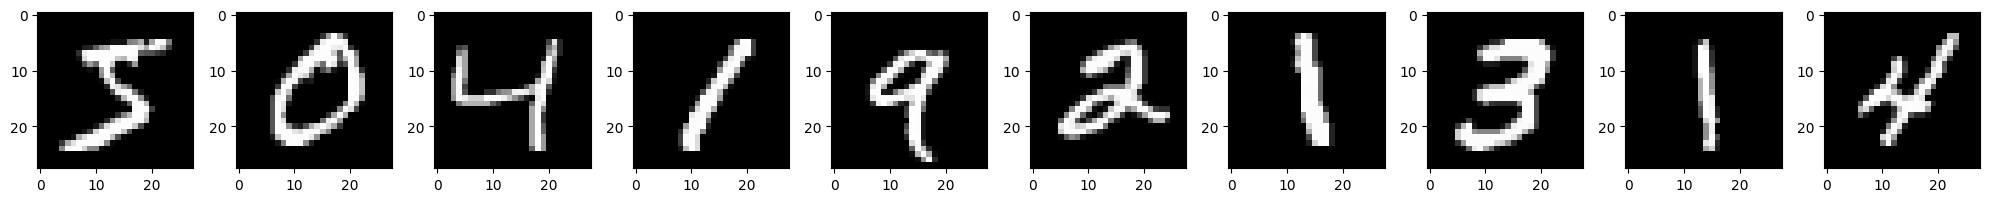

In [ ]:
# images visualisation
fig, ax = plt.subplots(nrows=1, ncols=10, figsize=(20, 6))
for i in range(10):
  ax[i].imshow(X_train[i], cmap='gray')

plt.tight_layout()
plt.show()

In [ ]:
y_train[4]

np.uint8(9)

In [ ]:
X_train[4]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0

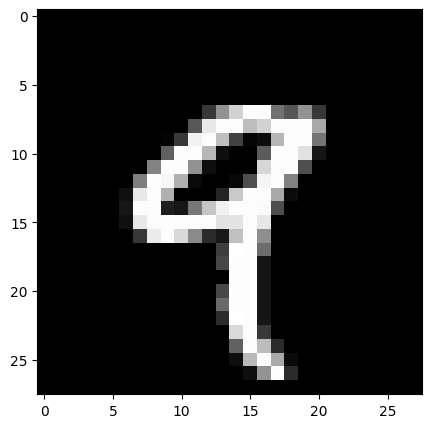

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(X_train[4], cmap='gray')
plt.show()

In [ ]:
np.set_printoptions(linewidth = 200)

# Normalization

In [ ]:

print('trainset:', X_train.shape) # 60,000 images
print('testset:', X_test.shape) # 10,000 images

# Normalisation des données
X_train = X_train / 255
X_test = X_test / 255


trainset: (60000, 28, 28)
testset: (10000, 28, 28)


In [ ]:
X_train[3]

array([[0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.        , 0.

 Configuration des Couches du Réseau de Neurones

In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
np.random.randint(0, X_train.shape[0])

54121

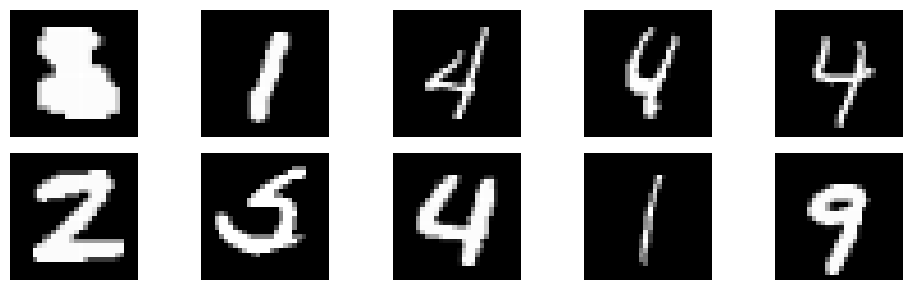

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(10, 3))
# random integer value

for i in range(10):  # Adjust the range to 10 since you have 2 rows of 5 images each
    # Compute the row and column index
    rnd = np.random.randint(0, X_train.shape[0])
    row = i // 5
    col = i % 5
    ax[row, col].imshow(X_train[rnd], cmap='gray')
    ax[row, col].axis('off')  # Optionally turn off the axis

plt.tight_layout()
plt.show()

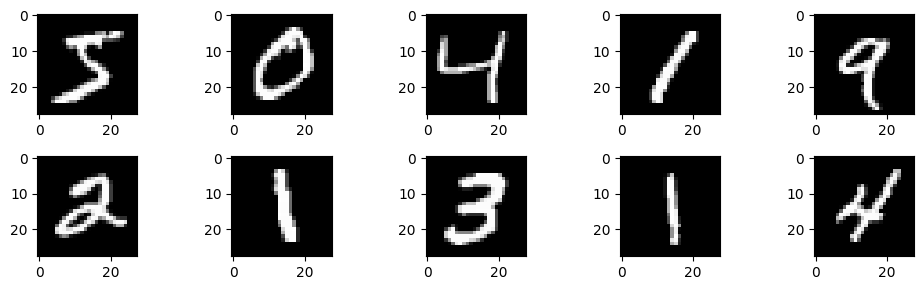

In [ ]:
# image visualisation
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(10, 3))
for i in range(10):
  ax[i//5, i%5 ].imshow(X_train[i], cmap='gray')

plt.tight_layout()
plt.show()

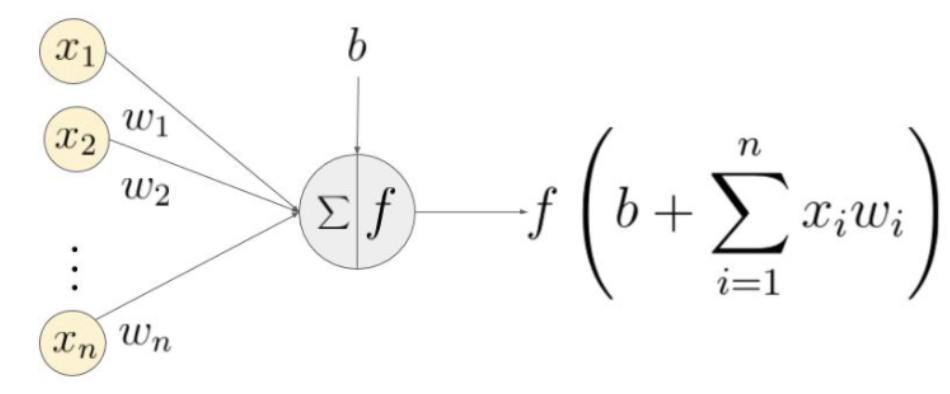

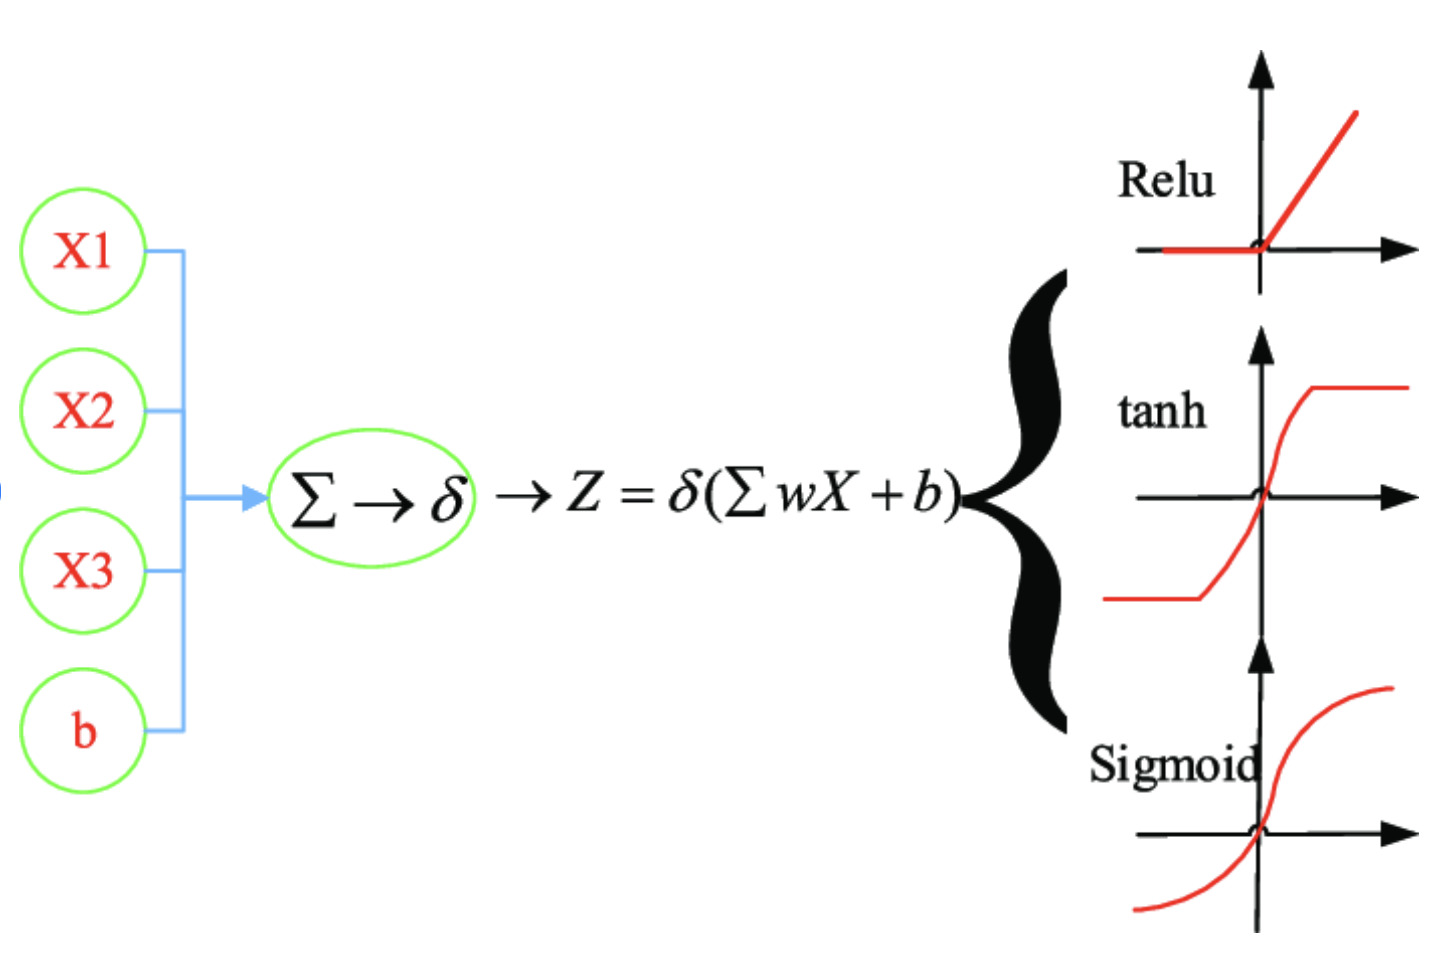

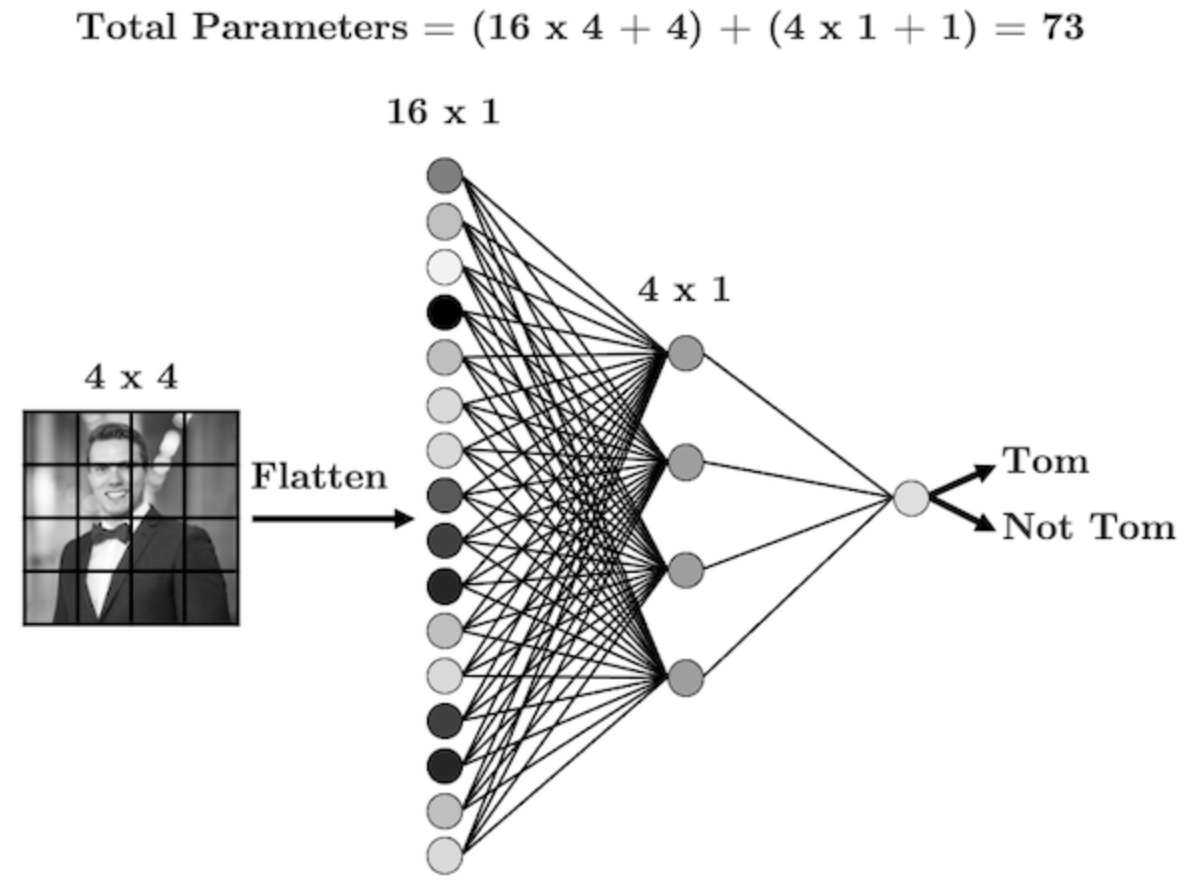

In [ ]:
import keras
from keras.layers import Input, Flatten, Dense

# Layer configuration
model = keras.Sequential([
    # Add Input layer to define the input shape first
    Input(shape=(28, 28)),

    # Flatten layer: Now does not need input_shape
    # Converts the 2D image data (28x28 pixels) into a 1D array of 784 pixels (28*28).
    Flatten(),

    # First Dense layer: A fully connected layer of 128 neurons. Uses the ReLU activation function.
    # ReLU is chosen because it performs well in neural networks by introducing non-linearity.
    Dense(128, activation='relu'),

    # Second Dense layer: Another fully connected layer of 128 neurons, also with ReLU activation.
    # This adds additional capacity to the model to learn more complex patterns.
    Dense(128, activation='relu'),

    # Output layer: A dense layer with 10 neurons, each representing one of the class labels (0-9).
    # This layer does not use an activation function here as it's typical to use 'softmax' in the loss function
    # for multiclass classification, which is done outside this code block.
    Dense(10)
    # The output size is 10, corresponding to the 10 possible classes (digits 0 through 9).
])

### Explanation of the Flatten Layer:
<p style="font-family: 'Courier New', monospace; text-align: Justified;">
The Flatten layer is used as the first layer in models that process image data. It transforms the format of the images from a 2D array (in case of grayscale images, where the two dimensions represent image height and width) to a 1D array. The length of this 1D array is equal to the product of the dimensions of the 2D array. In this case, since each image is 28x28 pixels, the output array will have a length of 784 pixels. This transformation is necessary because the next layers in the network, the dense layers, require input data in a flat, 1D format. The Flatten layer does not learn any parameters; it simply changes the shape of the input data so it can be processed by the dense layers that follow.</p>

In [ ]:
28*28*128+128

100480

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

Entrainement du Réseau de Neurones

In [ ]:
# Compilation du modele
model.compile(optimizer='adam',
    loss= keras.losses.SparseCategoricalCrossentropy(
        from_logits=True),
        metrics=['accuracy'])
# Entrainement du modele
model.fit(X_train, y_train, epochs=3)

Epoch 1/3


2025-04-08 09:55:35.695302: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8867 - loss: 0.3920
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9694 - loss: 0.1018
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9801 - loss: 0.0643


In [ ]:
# Model Evaluation
test_loss, test_acc = model.evaluate(X_test,  y_test)
print('Test accuracy:', test_acc)

 47/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9746 - loss: 0.0735   

2025-04-08 09:55:51.024711: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9705 - loss: 0.0888
Test accuracy: 0.9758999943733215


In [ ]:
# Multiclass classification Predicton Model  (softmax)
prediction_model = keras.Sequential([model, keras.layers.Softmax()])

In [ ]:
X_test.shape

(10000, 28, 28)

In [ ]:
np.expand_dims(X_test[4], axis=0).shape

(1, 28, 28)

In [ ]:
prediction_model.predict(np.expand_dims(X_test[4], axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([[7.1069792e-07, 6.5159867e-07, 2.1052024e-06, 1.2636480e-07, 9.8885906e-01, 2.2348028e-07, 1.3078912e-07, 6.3702908e-05, 3.6671372e-07, 1.1072974e-02]], dtype=float32)

In [ ]:
np.argmax(prediction_model.predict(np.expand_dims(X_test[4], axis=0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


np.int64(4)

In [ ]:

predict_proba = prediction_model.predict(X_test)
y_pred= np.argmax(predict_proba)

202/313 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step

2025-04-08 09:55:51.730812: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step


 Axctual Digit value : 4


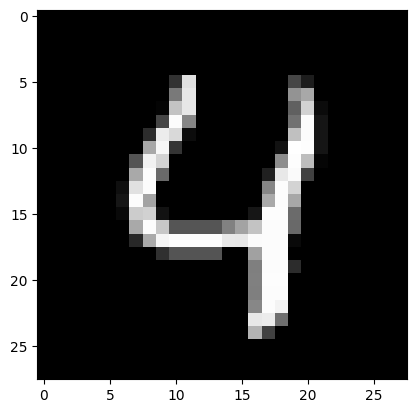

  Predicted Digit value 4


In [ ]:
print(f" Axctual Digit value : {y_test[4]}")
plt.imshow(X_test[4], cmap='gray')
plt.show()
print(f"  Predicted Digit value {np.argmax(predict_proba[4])}")

In [ ]:
y_test[4]

np.uint8(4)

In [ ]:
predict_proba[6]

array([4.3550381e-09, 2.0649140e-06, 8.0601374e-08, 1.5705247e-08, 9.9901974e-01, 1.0601744e-07, 2.2720009e-08, 1.9392023e-04, 4.3317679e-05, 7.4062630e-04], dtype=float32)

In [ ]:
y_test[6]== np.argmax(predict_proba[4] )

np.True_

In [ ]:
print(prediction_model.predict(X_test[:5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[[1.7143297e-08 5.8444726e-07 1.2880012e-06 1.9140231e-05 5.4450135e-11 7.2415038e-09 5.1219749e-13 9.9997699e-01 3.8033850e-08 1.8572225e-06]
 [5.9796399e-09 6.5382505e-06 9.9999285e-01 4.7159833e-07 3.0179945e-10 1.9109990e-10 2.1718444e-10 8.2017053e-11 1.0440852e-07 2.4369825e-12]
 [1.8026059e-06 9.9964261e-01 1.6287837e-05 1.9732458e-06 1.5195544e-04 6.6104882e-08 1.1233555e-05 1.1913806e-04 5.4004329e-05 8.8732236e-07]
 [9.9950731e-01 3.1253967e-07 3.0732309e-04 1.9703971e-06 4.1198014e-06 1.2626558e-06 9.3085720e-05 4.2088588e-05 3.2194375e-06 3.9190942e-05]
 [7.1069792e-07 6.5159867e-07 2.1052044e-06 1.2636467e-07 9.8885906e-01 2.2348071e-07 1.3078936e-07 6.3703032e-05 3.6671409e-07 1.1072979e-02]]


In [ ]:
#  determin the max value within each row of the matrix
np.argmax(prediction_model.predict(X_test[:5]), axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([7, 2, 1, 0, 4])

In [ ]:
import pandas as pd
pd.DataFrame({'y_test': y_test[:5], 'Predicted ':np.argmax(prediction_model.predict(X_test[:5]), axis=1) } )


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


,y_test,Predicted
0,7,7
1,2,2
2,1,1
3,0,0
4,4,4


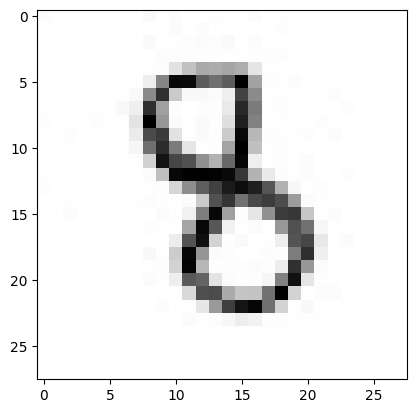

In [ ]:
# load jpg  image  "Digit.jpg" na duse the model to predict the digit
from PIL import Image
# import cv2
import numpy as np
# Load the image
image = Image.open('../resource/Digit.jpg')
# Convert the image to grayscale
image = image.convert('L')
# Resize the image to 28x28 pixels
image = image.resize((28, 28))
# Convert the image to a numpy array
image_array = np.array(image)
# plot the image
plt.imshow(image_array, cmap='gray')
plt.show()

In [ ]:
# Normalize the image array to the range [0, 1]
image_array = image_array / 255.0
# Add a batch dimension to the image array
image_array = np.expand_dims(image_array, axis=0)
# Predict the digit using the trained model
predicted_digit = prediction_model.predict(image_array)
# Get the predicted class (digit)
predicted_class = np.argmax(predicted_digit)
# Print the predicted class
print(f"Predicted digit: {predicted_class}")
# Load the image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicted digit: 5


# Mazen Digit Recognition
- Script to predict a single image using an EXISTING, pre-loaded Keras model variable.


![](../imgs/CNN.jpg)

![](../imgs/cnn-5.gif)

In [ ]:
from tensorflow.keras import layers
from keras.layers import Input, Flatten, Dense

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.layers.experimental.preprocessing import RandomRotation, RandomZoom, RandomTranslation

def build_robust_cnn(input_shape=(28, 28, 1), num_classes=10):
    """
    Builds a moderately deep CNN with augmentation, batch norm, pooling, dropout.

    Args:
        input_shape (tuple): Shape of input images (height, width, channels).
        num_classes (int): Number of output classes.

    Returns:
        keras.Model: The Keras model.
    """
    # Data Augmentation Layers
    data_augmentation = Sequential(
        [
           RandomRotation(0.1),
           RandomZoom(0.1),
           RandomTranslation(height_factor=0.1, width_factor=0.1),
        ],
        name="data_augmentation",
    )

    # Model Architecture
    model = keras.Sequential(
        [
            Input(shape=input_shape, name="input_image"),
            data_augmentation,
            # Conv Block 1
            Conv2D(32, kernel_size=(3, 3), padding="same", name="conv1"),
            BatchNormalization(name="bn1"),
            Activation("relu", name="relu1"),
            MaxPooling2D(pool_size=(2, 2), name="pool1"),
            # Conv Block 2
            Conv2D(64, kernel_size=(3, 3), padding="same", name="conv2a"),
            BatchNormalization(name="bn2a"),
            Activation("relu", name="relu2a"),
            
            Conv2D(64, kernel_size=(3, 3), padding="same", name="conv2b"),
            BatchNormalization(name="bn2b"),
            Activation("relu", name="relu2b"),
            MaxPooling2D(pool_size=(2, 2), name="pool2"),
            # Conv Block 3
            Conv2D(128, kernel_size=(3, 3), padding="same", name="conv3"),
            BatchNormalization(name="bn3"),
            Activation("relu", name="relu3"),
            MaxPooling2D(pool_size=(2, 2), name="pool3"),
            # Classifier Head
            Flatten(name="flatten"),
            Dropout(0.5, name="dropout1"),
            Dense(128, name="dense1"),
            BatchNormalization(name="bn_dense1"),
            Activation("relu", name="relu_dense1"),
            Dropout(0.5, name="dropout2"),
            Dense(num_classes, activation="softmax", name="output_softmax"),
        ],
        name="robust_digit_cnn",
    )
    return model

In [5]:
# Build and Compile Model ---
print("Building the CNN model...")
INPUT_SHAPE = (28, 28, 1) # For MNIST grayscale images
NUM_CLASSES = 10         # Digits 0-9

model = build_robust_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)

print("Compiling the model...")
# Use 'sparse_categorical_crossentropy'
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)


Building the CNN model...


NameError: name 'keras' is not defined

In [ ]:
# Print model summary
model.summary()

Model: "robust_digit_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2a (BatchNormalization)       │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2a (Activation)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2b (BatchNormalization)       │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2b (Activation)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense1 (BatchNormalization)  │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense1 (Activation)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,138 (1.07 MB)

 Trainable params: 279,306 (1.07 MB)

 Non-trainable params: 832 (3.25 KB)

In [6]:
X_train.shape , X_test.shape

NameError: name 'X_train' is not defined

In [36]:
np.expand_dims(X_train, -1).shape

(60000, 28, 28, 1)

In [37]:
x_train = np.expand_dims(X_train, -1) # Adds the channel dimension
x_test = np.expand_dims(X_test, -1)     # Adds the channel dimension
print(f"- Reshaped data: x_train={x_train.shape}, x_test={x_test.shape}")

- Reshaped data: x_train=(60000, 28, 28, 1), x_test=(10000, 28, 28, 1)


In [38]:
print("\nStarting model training...")
# Callbacks for enhanced training control


callbacks = [
    # Stop training early if `val_loss` doesn't improve for `patience` epochs
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=1),
    # Save only the best model weights based on validation accuracy
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_digit_model_weights.weights.h5', # Use .weights.h5 extension
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True, # Save only weights
        verbose=1
        )
]



Starting model training...


In [39]:
# Uses x_test as validation data in this example; ideally, use a separate validation set


BATCH_SIZE = 128  # Number of samples per gradient update
EPOCHS = 20       # Number of epochs to train for (adjust based on results)
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test, y_test), # Using test set as validation here
    callbacks=callbacks
)

Epoch 1/20


2025-04-08 09:55:53.074449: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


  1/469 ━━━━━━━━━━━━━━━━━━━━ 32:17 4s/step - accuracy: 0.0859 - loss: 3.0737

2025-04-08 09:55:57.243689: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 22127616 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.6872 - loss: 0.9709
Epoch 1: val_accuracy improved from -inf to 0.95160, saving model to best_digit_model_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 123s 254ms/step - accuracy: 0.6875 - loss: 0.9699 - val_accuracy: 0.9516 - val_loss: 0.1707
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9457 - loss: 0.1825
Epoch 2: val_accuracy improved from 0.95160 to 0.96280, saving model to best_digit_model_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 251ms/step - accuracy: 0.9457 - loss: 0.1825 - val_accuracy: 0.9628 - val_loss: 0.1120
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9616 - loss: 0.1297
Epoch 3: val_accuracy improved from 0.96280 to 0.98310, saving model to best_digit_model_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 250ms/step - accuracy: 0.9616 - loss: 0.1297 - val_accuracy: 0.9831 - val_loss: 0.0532
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accurac

In [42]:
print("\nEvaluating the best model saved during training...")
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Loss (Best Model): {test_loss:.4f}")
print(f"Test Accuracy (Best Model): {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")



Evaluating the best model saved during training...

Test Loss (Best Model): 0.0443
Test Accuracy (Best Model): 0.9866 (98.66%)


In [44]:
from PIL import Image, ImageOps # Using Pillow (PIL) for image handling
import matplotlib.pyplot as plt # To display the image (optional)

# load image and convert it to gray Scale
img = Image.open('../resource/Digit.jpg')

img_gray = ImageOps.grayscale(img)
print("- Converted to grayscale")

# Resize to 28x28 pixels
try:
  resampling_filter = Image.Resampling.LANCZOS
except AttributeError:
        resampling_filter = Image.LANCZOS # For older Pillow versions
img_resized = img_gray.resize((28, 28), resampling_filter)
print("- Resized to 28x28 pixels")

- Converted to grayscale
- Resized to 28x28 pixels


In [46]:
# Convert image to NumPy array
img_array = np.array(img_resized)

# Normalize pixel values to [0, 1] range
img_normalized = img_array.astype("float32") / 255.0
print(f"- Normalized pixel values (min: {img_normalized.min():.2f}, max: {img_normalized.max():.2f})")


- Normalized pixel values (min: 0.02, max: 1.00)


In [47]:
img_normalized.shape

(28, 28)

In [48]:
# Reshape for the model's input layer (add batch and channel dims)
# Expected shape: (1, 28, 28, 1)
img_reshaped = np.expand_dims(img_normalized, axis=-1) # Add channel dimension
img_reshaped = np.expand_dims(img_reshaped, axis=0)# Add batch dimension
print(f"- Reshaped image for model input: {img_reshaped.shape}")

- Reshaped image for model input: (1, 28, 28, 1)


- Displaying processed image (optional)...


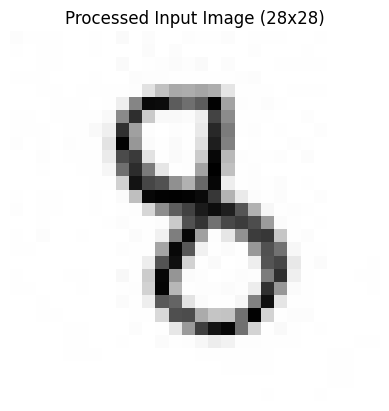

In [49]:

# --- Optional: Display the processed image ---
print("- Displaying processed image (optional)...")
plt.imshow(img_normalized, cmap='gray')
plt.title(f"Processed Input Image (28x28)")
plt.axis('off')
plt.show()

In [50]:
# Use the existing 'model' variable to predict
predictions = model.predict(img_reshaped)
print(f"Raw prediction output (probabilities): \n{predictions}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Raw prediction output (probabilities): 
[[6.2433846e-04 6.3349453e-06 2.1551019e-03 3.3683054e-02 2.8361395e-04 1.5040366e-03 5.8491138e-04 1.6184056e-05 9.5024329e-01 1.0899175e-02]]


In [51]:
# Interpret the results
predicted_class = np.argmax(predictions[0])
confidence = np.max(predictions[0])

print("\n--- Prediction Result ---")
print(f"Predicted Digit: {predicted_class}")
print(f"Confidence:  {confidence:.4f} ({confidence*100:.2f}%)")
print("------------------------")


--- Prediction Result ---
Predicted Digit: 8
Confidence:  0.9502 (95.02%)
------------------------
